# Data Analyst

Load `air_fryers_clean_brand_year.csv`.


In [11]:
import pandas as pd
import numpy as np

airfryer = pd.read_csv('../data/air_fryers_clean_brand_year.csv')
airfryer.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [29]:
airfryer.shape

(50, 16)

1. Verify that the data contain 10 brands and the years 2019-2023.


In [12]:
airfryer['brand'].nunique()

10

In [23]:
airfryer['year'].unique()

array([2019, 2020, 2021, 2022, 2023])

In [28]:
airfryer.groupby("year")["brand_share"].sum().reset_index(name="total share")

,year,total share
0,2019,1.0
1,2020,1.0
2,2021,1.0
3,2022,1.0
4,2023,1.0


2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
   


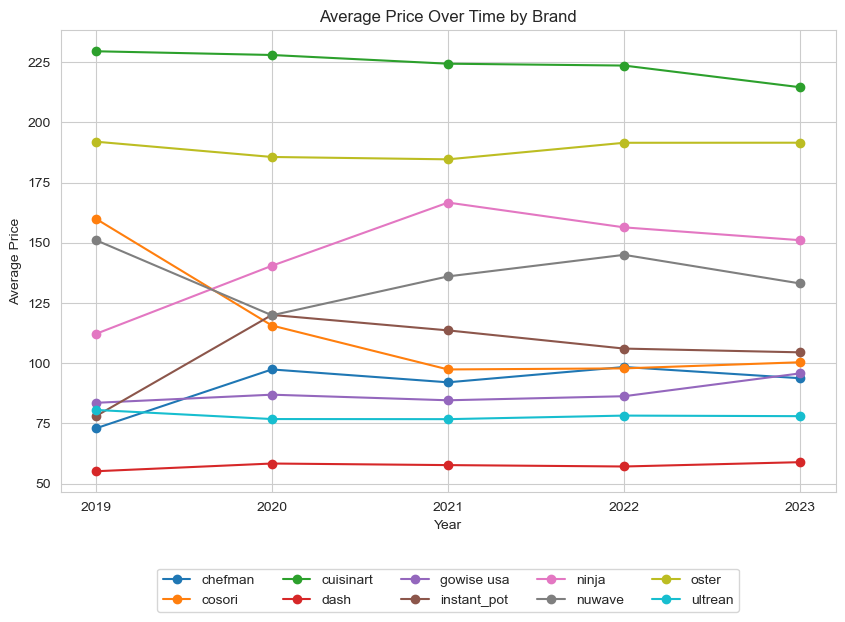

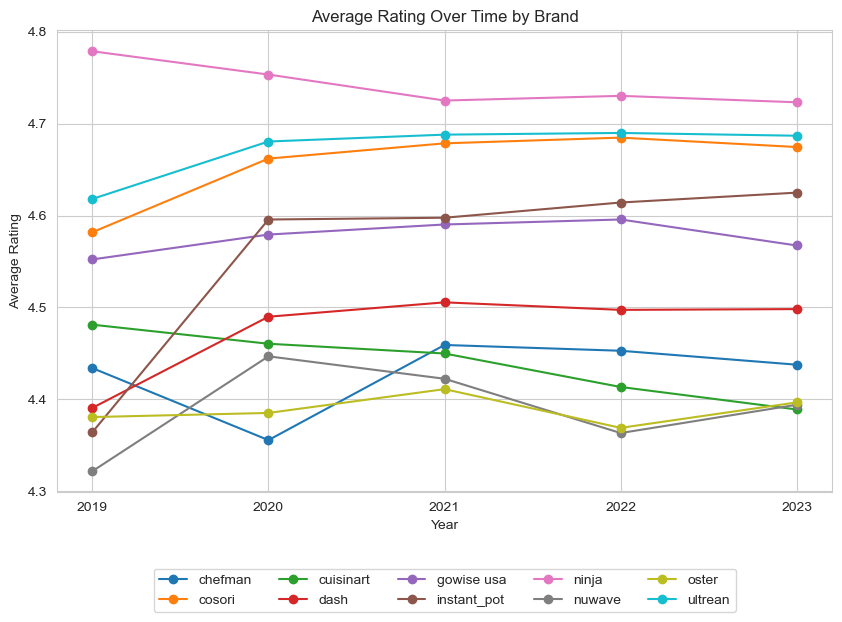

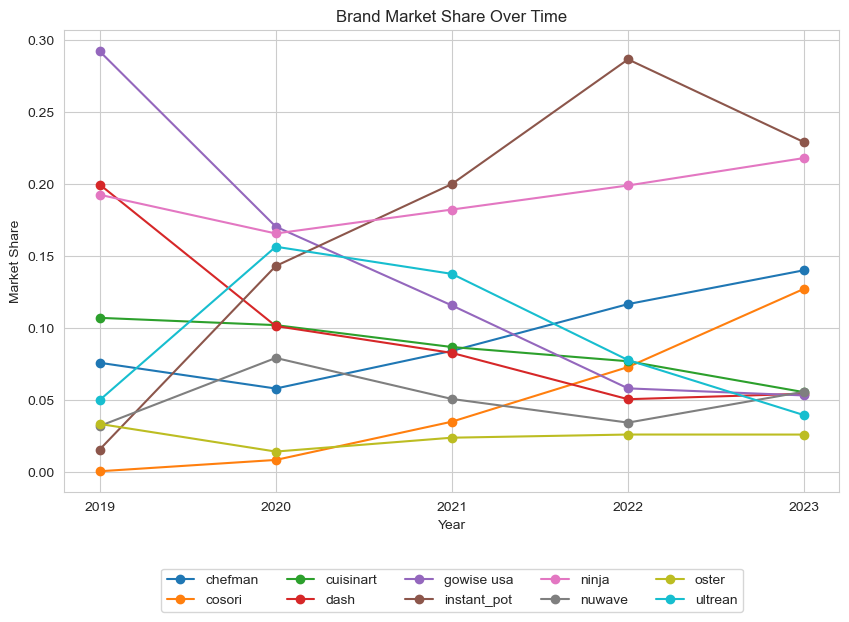

In [26]:
import matplotlib.pyplot as plt

brands = airfryer['brand'].unique()

plt.figure(figsize=(10, 6))
for b in brands:
    df_b = airfryer[airfryer['brand'] == b]
    plt.plot(df_b['year'], df_b['avg_price'], marker='o', label=b)

plt.title('Average Price Over Time by Brand')
plt.xticks(sorted(airfryer['year'].unique()))
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
plt.show()

plt.figure(figsize=(10, 6))
for b in brands:
    df_b = airfryer[airfryer['brand'] == b]
    plt.plot(df_b['year'], df_b['avg_rating'], marker='o', label=b)

plt.title('Average Rating Over Time by Brand')
plt.xticks(sorted(airfryer['year'].unique()))
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
plt.show()


plt.figure(figsize=(10, 6))
for b in brands:
    df_b = airfryer[airfryer['brand'] == b]
    plt.plot(df_b['year'], df_b['brand_share'], marker='o', label=b)

plt.title('Brand Market Share Over Time')
plt.xticks(sorted(airfryer['year'].unique()))
plt.xlabel('Year')
plt.ylabel('Market Share')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5)
plt.show()

3. Summarize the product characteristics:
   - Which features are common? 
      - **The most common feature across brands was the compact feature, having comprised 98% of products on the market. It seems that the compact-style of airfryer is the industry standard. The next most common is oven-style, present in roughly 56% of products, indicating a significant secondary design category. Since it is prevalent in over a majority of the market, it seems that the oven-style is another popular choice across brands, rather than a feature which differentiates brands.**
   - Which features are rare? 
      - **The features rotisserie, window, and dual-basket are relatively rare, each contributing to less than 10% of the market. Dual-basket making up only 0.2% of the market suggests that customers have yet to desire a product that simultaneously cooks two foods at once.**
   - Are there brands that seem to specialize in different product types? 
      - **Yes, there is clear evidence that brands specialize in different product types. Brands like Cuisinart, Dash, Oster, and Ultrean are strongly associated with oven-style products, showing consistently high oven-style shares. Cosori stands out as heavily compact-focused with minimal diversification into other features. On the other hand, Chefman appears more diversified across oven-style, rotisserie, and window features, suggesting a broader product strategy. GoWise USA also shows some specialization toward additional features like window and rotisserie functions. Overall, most brands lean toward either compact dominance or oven-style specialization, with only a few exhibiting broader style variation.**

In [ ]:
# Which features are common/rare?
features = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]

common_features = airfryer[features].mean().sort_values(ascending=False)
print("Average Feature Shares:")
print(common_features)

Average Feature Shares:
compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64


In [33]:
# Are there brands that seem to specialize in different product types?
brand_features = airfryer.groupby('brand')[features].mean().reset_index()

brand_features = brand_features.round(3)

brand_features

,brand,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share
0,chefman,0.962,0.013,0.597,0.370,0.363
1,cosori,0.997,0.000,0.030,0.024,0.000
2,cuisinart,0.996,0.000,0.913,0.000,0.000
3,dash,0.999,0.000,0.890,0.000,0.000
4,gowise usa,1.000,0.000,0.184,0.184,0.001
5,instant_pot,0.860,0.000,0.675,0.102,0.003
6,ninja,0.992,0.002,0.100,0.000,0.000
7,nuwave,0.995,0.007,0.543,0.027,0.000
8,oster,1.000,0.000,0.865,0.000,0.000
9,ultrean,1.000,0.000,0.830,0.000,0.000


4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?
    - **The market shows clear price tiers and shifting share dynamics from 2019–2023. Premium brands like Cuisinart and Ninja consistently have the highest average prices, with Oster is also positioned in the upper-mid range. In contrast, Dash, Ultrean, and Chefman compete at lower price points. In terms of market share, Instant Pot and Ninja hold large and growing shares by the end of the period, while Cosori also expereinced a steady increase in share across the five years. Meanwhile, GoWISE USA, Dash, and NuWave lose share over time. Overall, the market does not look fully stable due to the noticeable shifts in share, particularly between 2020 and 2022. However, prices and ratings remain relatively steady year over year.**

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.